
# INF-473 - Introducción a la Inteligencia Artificial Explicable
## 1er Semestre 2026 -- Prof. Raquel Pezoa

___
# Modelos Transparentes: Regresión Lineal

La **regresión lineal** es uno de los modelos más simples e interpretables en machine learning.

Sus predicciones se expresan como una **combinación lineal de las variables de entrada**, lo que permite entender directamente cómo cada variable influye en la predicción.

Por esta razón, la regresión lineal suele considerarse un **modelo transparente**.

En este notebook vamos a:

1. Recordar la intuición detrás de la regresión lineal  
2. Ajustar un modelo sobre un dataset simple  
3. Interpretar los coeficientes del modelo  
4. Aplicar regresión lineal al dataset Iris  
5. Extender el modelo a regresión múltiple

## 1. El modelo de regresión lineal

La regresión lineal modela la relación entre una variable dependiente $y$ y una o más variables independientes $x$.

Para una sola variable explicativa, el modelo es:

$$
y = \beta_0 + \beta_1 x + \epsilon
$$

donde:

- $\beta_0$ es el **intercepto**
- $\beta_1$ es la **pendiente**
- $\epsilon$ representa el error o ruido

Los parámetros del modelo se estiman usando **Ordinary Least Squares (OLS)**, que minimiza la suma de los errores cuadrados:

$$
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Debido a que el modelo es lineal, los coeficientes pueden **interpretarse directamente**.

## 2. Ejemplo: Edad vs Presión arterial

Comenzaremos con un pequeño dataset sintético que relaciona:

- edad
- presión arterial

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# Dataset simple

edad = np.array([25, 30, 35, 40, 45, 50, 55, 60])
presion = np.array([120, 122, 125, 130, 135, 140, 142, 150])

Primero visualizamos los datos.

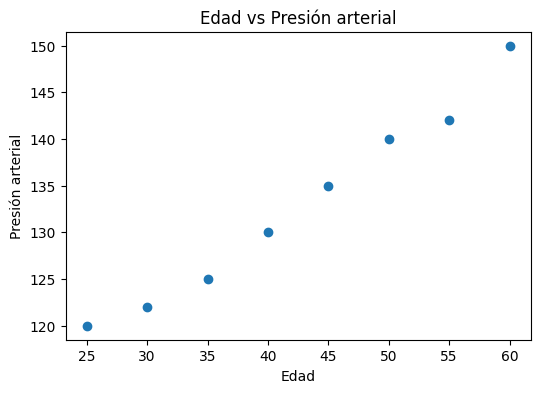

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(edad, presion)

plt.xlabel("Edad")
plt.ylabel("Presión arterial")
plt.title("Edad vs Presión arterial")

plt.show()

Ahora ajustamos un **modelo de regresión lineal**.

In [6]:
# sklearn espera una matriz 2D como entrada
X = edad.reshape(-1,1)
y = presion

modelo = LinearRegression()
modelo.fit(X, y)

predicciones = modelo.predict(X)
print("Pendiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

print("R^2:", r2_score(y, predicciones))
print("MSE:", mean_squared_error(y, predicciones))

Pendiente: 0.8571428571428571
Intercepto: 96.57142857142858
R^2: 0.9814612868047983
MSE: 1.8214285714285725


### Interpretación

La **pendiente** indica cuánto cambia la presión arterial predicha cuando la edad aumenta en una unidad.

Por ejemplo, si la pendiente fuera aproximadamente **0.9**, esto significaría que:

> por cada año adicional de edad, la presión arterial esperada aumenta en aproximadamente **0.9 unidades**.

El **intercepto** corresponde al valor predicho cuando $x = 0$.

En muchos problemas este valor no tiene una interpretación práctica directa.

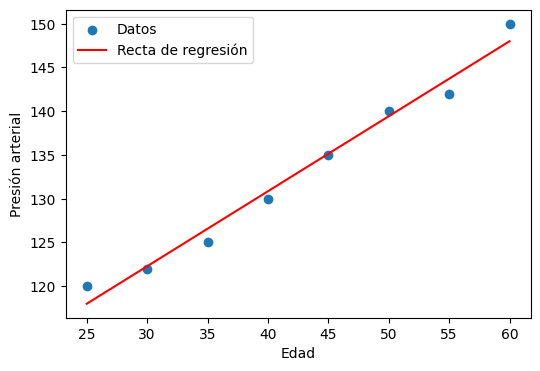

In [7]:
plt.figure(figsize=(6,4))

plt.scatter(edad, presion, label="Datos")
plt.plot(edad, predicciones, color="red", label="Recta de regresión")

plt.xlabel("Edad")
plt.ylabel("Presión arterial")

plt.legend()

plt.show()

## 3. Regresión lineal en el dataset Iris

Ahora utilizaremos un dataset real muy conocido en machine learning: **Iris**.

Nos enfocaremos en la especie **Iris-versicolor** y estudiaremos la relación entre:

- largo del pétalo
- ancho del pétalo

In [9]:
import pandas as pd
import seaborn as sns

In [10]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columnas = [
    "Sepal_Length",
    "Sepal_Width",
    "Petal_Length",
    "Petal_Width",
    "Species"
]

iris = pd.read_csv(url, names=columnas)

iris.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Seleccionamos solamente los datos correspondientes a **Iris-versicolor**.

In [11]:
versicolor = iris[iris["Species"] == "Iris-versicolor"]

versicolor.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
50,7.0,3.2,4.7,1.4,Iris-versicolor
51,6.4,3.2,4.5,1.5,Iris-versicolor
52,6.9,3.1,4.9,1.5,Iris-versicolor
53,5.5,2.3,4.0,1.3,Iris-versicolor
54,6.5,2.8,4.6,1.5,Iris-versicolor


### Visualización de los datos

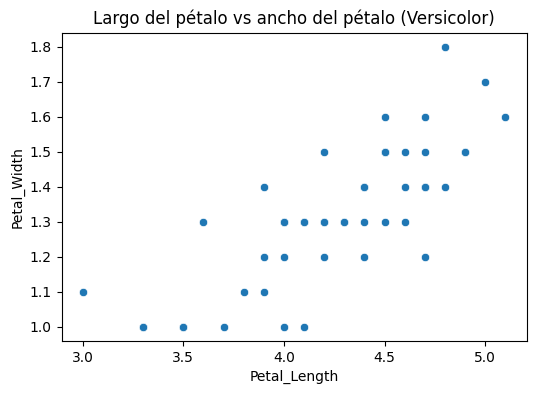

In [12]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=versicolor,
    x="Petal_Length",
    y="Petal_Width"
)

plt.title("Largo del pétalo vs ancho del pétalo (Versicolor)")

plt.show()

## 4. Regresión lineal con statsmodels

La librería `statsmodels` permite obtener un resumen estadístico mucho más completo del modelo.

Esto es útil cuando queremos **interpretar los coeficientes y analizar su significancia estadística**.

In [13]:
import statsmodels.formula.api as smf

In [15]:
modelo_ols = smf.ols(
    "Petal_Width ~ Petal_Length",
    data=versicolor
).fit()

modelo_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Petal_Width   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     77.93
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.27e-11
Time:                        17:34:16   Log-Likelihood:                 34.709
No. Observations:                  50   AIC:                            -65.42
Df Residuals:                      48   BIC:                            -61.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0843      0.161     -0.525      0.602      -0.407       0.239
Petal_Length     0.3311      0.038      8.828      0.000       0.256       0.406
==============================================================================
Omnibus:                        0.204   Durbin-Watson:                   2.412
Prob(Omnibus):                  0.903   Jarque-Bera (JB):                0.002
Skew:                          -0.012   Prob(JB):                        0.999
Kurtosis:                       3.017   Cond. No.                         41.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretación de los resultados

En el resumen del modelo aparecen varias cantidades importantes:

**Coeficiente**

Indica cuánto cambia el valor predicho cuando la variable aumenta en una unidad.

**p-value**

Permite evaluar si el coeficiente es significativamente distinto de cero.

**R²**

Indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

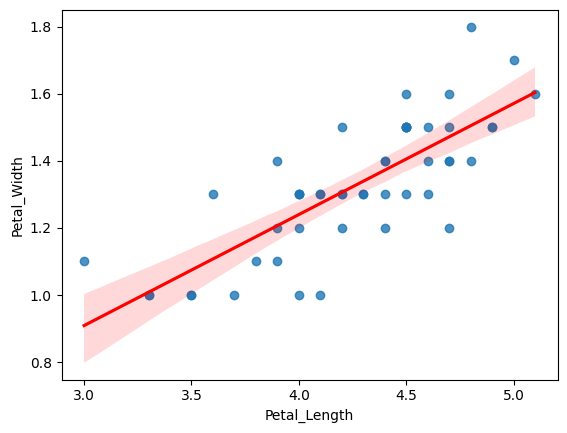

In [16]:
sns.regplot(
    data=versicolor,
    x="Petal_Length",
    y="Petal_Width",
    line_kws={"color":"red"}
)

plt.show()

## 5. Regresión lineal múltiple

La regresión lineal también puede utilizar **más de una variable explicativa**.

Por ejemplo, podemos predecir **Petal Width** usando:

- Petal Length
- Sepal Length
- Sepal Width

En regresión múltiple, cada coeficiente se interpreta como el cambio esperado en la variable objetivo cuando esa variable aumenta en una unidad **manteniendo las demás constantes**.

In [17]:
modelo_multiple = smf.ols(
    "Petal_Width ~ Petal_Length + Sepal_Length + Sepal_Width",
    data=versicolor
).fit()

### Preguntas

1. ¿Qué variable parece tener mayor influencia en **Petal Width**?
2. ¿Cuál es el valor de $R^2$?
3. ¿Todos los coeficientes son estadísticamente significativos?
4. ¿Cómo se compara este modelo con la regresión simple?

## 6. Discusión

La regresión lineal es considerada un **modelo transparente** porque sus parámetros pueden ser inspeccionados directamente.

Sin embargo, es importante recordar que:

> interpretabilidad no implica causalidad.

Una variable puede tener un coeficiente alto en un modelo predictivo sin necesariamente ser la causa real del fenómeno.

## Ideas clave

- La regresión lineal es uno de los modelos más simples e interpretables en machine learning.
- Los coeficientes indican la **dirección** y **magnitud** del efecto de cada variable.
- En regresión múltiple, cada coeficiente se interpreta **condicional a las demás variables**.
- Los modelos transparentes permiten entender el proceso de predicción.

## Ejercicio opcional

Repita el análisis utilizando otra especie del dataset Iris.

Sugerencias:

- **Iris-setosa**
- **Iris-virginica**

Compare:

1. Los coeficientes del modelo
2. El valor de $R^2$
3. La calidad del ajuste lineal